Import libraries


In [4]:
import pandas as pd
import seaborn as sns
import ast
import matplotlib.pyplot as plt
import numpy as np
pd.set_option('display.max_columns', None)

In [5]:
recipes=pd.read_csv("recipes.csv")
reviews=pd.read_csv("reviews.csv")                    

In [7]:
# ============================================
# 3. BASIC COUNTS
# ============================================

print("Users:", reviews['AuthorId'].nunique())
print("Recipes:", recipes['RecipeId'].nunique())
print("Total Reviews:", len(reviews))


Users: 271907
Recipes: 522517
Total Reviews: 1401982


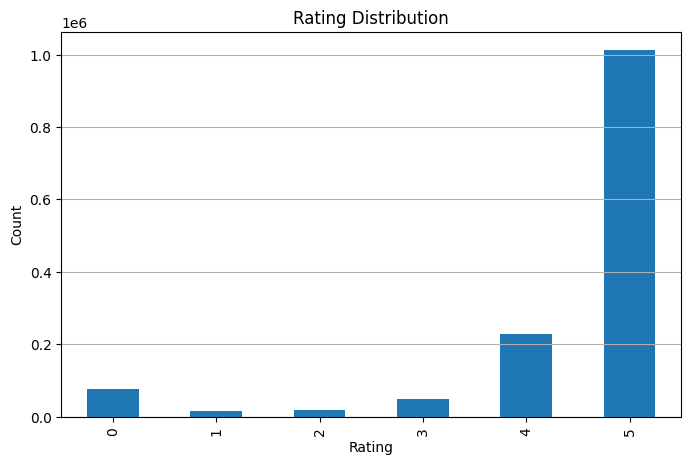

In [15]:
plt.figure(figsize=(8,5))
reviews['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.grid(axis='y')
plt.show()

In [27]:
top_recipes = reviews.groupby('RecipeId')['Rating'].count().sort_values(ascending=False).head(10)

print("Top Recipes by Review Count:")
print(top_recipes)

Top Recipes by Review Count:
RecipeId
45809    2892
2886     2182
27208    1614
89204    1584
39087    1491
67256    1359
35813    1353
54257    1325
22782    1273
32204    1228
Name: Rating, dtype: int64


In [28]:
print("Missing Values in Recipes:")
print(recipes.isnull().sum())

print("\nMissing Values in Reviews:")
print(reviews.isnull().sum())

Missing Values in Recipes:
RecipeId                           0
Name                               0
AuthorId                           0
AuthorName                         0
CookTime                       82545
PrepTime                           0
TotalTime                          0
DatePublished                      0
Description                        5
Images                             1
RecipeCategory                   751
Keywords                       17237
RecipeIngredientQuantities         3
RecipeIngredientParts              0
AggregatedRating              253223
ReviewCount                   247489
Calories                           0
FatContent                         0
SaturatedFatContent                0
CholesterolContent                 0
SodiumContent                      0
CarbohydrateContent                0
FiberContent                       0
SugarContent                       0
ProteinContent                     0
RecipeServings                182911
RecipeYield

In [35]:
data = pd.merge(reviews, recipes, on='RecipeId')

print("Merged Shape:", data.shape)
display(data.head())

Merged Shape: (1401963, 35)


,ReviewId,RecipeId,AuthorId_x,AuthorName_x,Rating,Review,DateSubmitted,DateModified,Name,AuthorId_y,AuthorName_y,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,RecipeCategory,Keywords,RecipeIngredientQuantities,RecipeIngredientParts,AggregatedRating,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25T21:44:00Z,2000-01-25T21:44:00Z,Jalapeno Pepper Poppers,1545,Nancy Van Ess,NaN,PT30M,PT30M,1999-09-06T04:28:00Z,Make and share this Jalapeno Pepper Poppers re...,"""https://img.sndimg.com/food/image/upload/w_55...",Vegetable,"c(""< 30 Mins"", ""For Large Groups"")","c(""8"", ""4"", ""4"", ""6"", ""1/4"", ""1/4"", ""1/4"", ""1""...","c(""cream cheese"", ""sharp cheddar cheese"", ""mon...",5.0,15.0,111.4,9.2,4.9,23.7,172.5,3.2,0.6,0.9,4.3,24.0,NaN,"c(""In a mixing bowl, combine cheeses, bacon an..."
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z,Curry Dip,1920,Ruth Dearing,PT2H,PT5M,PT2H5M,1999-11-29T23:41:00Z,Make and share this Curry Dip recipe from Food...,character(0),Weeknight,"c(""Refrigerator"", ""< 4 Hours"", ""Easy"")","c(""1 1/2"", ""1/2"", ""2"", ""1/4"", ""1"", NA)","c(""mayonnaise"", ""salt"", ""curry powder"", ""black...",5.0,3.0,4.6,0.1,0.0,0.0,291.3,0.9,0.4,0.1,0.2,4.0,NaN,"c(""Combine all in a bowl and mix thoroughly."",..."
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25T09:00:00Z,2000-02-25T09:00:00Z,Chinese Imperial Palace General Tso's Chicken,1932,Sealoverz,PT30M,PT30M,PT1H,1999-11-15T05:00:00Z,Make and share this Chinese Imperial Palace Ge...,character(0),Chicken Breast,"c(""Chicken"", ""Poultry"", ""Meat"", ""Chinese"", ""As...","c(""1/2"", ""1/4"", ""1 1/2"", ""1 1/2"", ""3/4"", ""1/2""...","c(""cornstarch"", ""water"", ""fresh garlic"", ""fres...",4.0,10.0,420.7,5.7,1.4,133.1,2077.6,45.5,1.3,20.3,43.0,8.0,NaN,"c(""Combine all ingredients for sauce in a quar..."
3,13,7435,1773,Malarkey Test,5,easily the best i have ever had. juicy flavor...,2000-03-13T21:15:00Z,2000-03-13T21:15:00Z,Kevin's Best Corned Beef,1986,Kevin Connolly,PT3H20M,PT1H15M,PT4H35M,2000-03-11T15:27:00Z,Make and share this Kevin's Best Corned Beef r...,"c(""https://img.sndimg.com/food/image/upload/w_...",Meat,"c(""European"", ""Winter"", ""Weeknight"", ""St. Patr...","c(""1 3/4"", ""2 1/2"", ""6"", ""1"", ""6"", ""1"", ""1"", ""...","c(""onions"", ""carrots"", ""corned beef brisket"", ...",5.0,47.0,756.6,44.3,14.6,222.1,2783.7,41.5,9.5,11.8,47.0,12.0,NaN,"c(""Use a 14 to 20 qt. pan."", ""Coarsely chop en..."
4,14,44,2085,Tony Small,5,An excellent dish.,2000-03-28T12:51:00Z,2000-03-28T12:51:00Z,Warm Chicken A La King,1596,Joan Edington,PT3M,PT35M,PT38M,1999-09-17T04:47:00Z,I copied this one out of a friend's book so ma...,"""https://img.sndimg.com/food/image/upload/w_55...",Chicken,"c(""Poultry"", ""Meat"", ""< 60 Mins"")","c(""12"", ""2"", ""3"", ""450"", ""1"", ""2"", ""1/4"", ""1"",...","c(""chicken"", ""butter"", ""flour"", ""milk"", ""celer...",5.0,23.0,895.5,66.8,31.9,405.8,557.2,29.1,3.1,5.0,45.3,2.0,NaN,"c(""Melt 1 1/2 ozs butter, add the flour and co..."


Top Categories:
RecipeCategory
Dessert          62072
Lunch/Snacks     32586
One Dish Meal    31345
Vegetable        27231
Breakfast        21101
Beverages        16076
Chicken          13249
Meat             13131
Breads           12804
Pork             12603
Name: count, dtype: int64


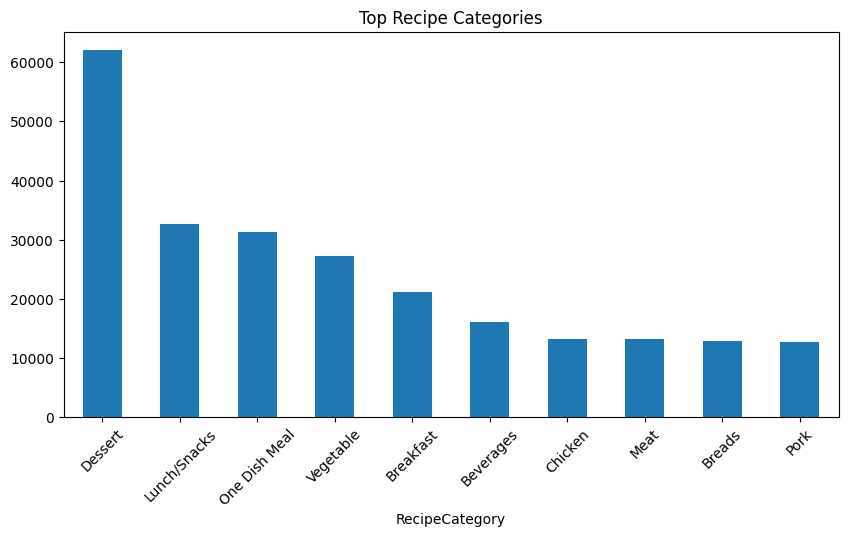

In [37]:
top_categories = recipes['RecipeCategory'].value_counts().head(10)

print("Top Categories:")
print(top_categories)

plt.figure(figsize=(10,5))
top_categories.plot(kind='bar')
plt.title("Top Recipe Categories")
plt.xticks(rotation=45)
plt.show()

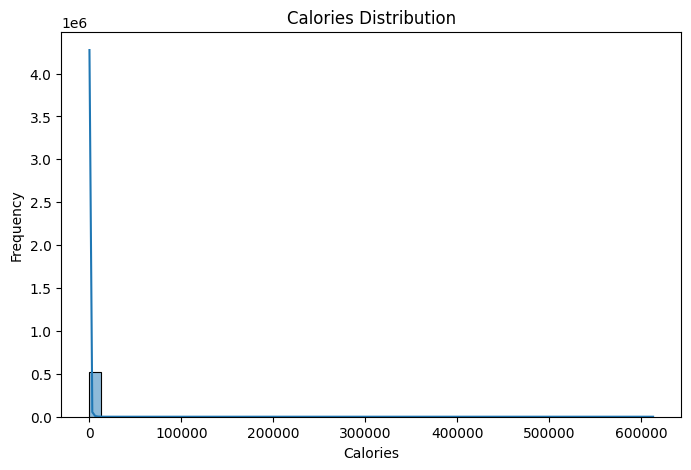

In [39]:
plt.figure(figsize=(8,5))
sns.histplot(recipes['Calories'], bins=50, kde=True)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

Top Ingredients:
e    13543
a     9310
r     8003
      7467
s     6116
c     5778
i     5576
t     5523
o     5301
l     5049
Name: count, dtype: int64


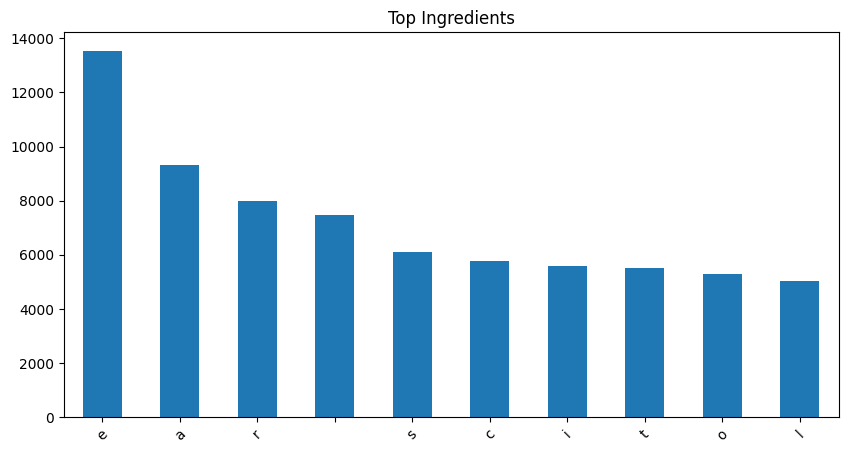

In [41]:
import ast

def safe_eval(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

recipes['RecipeIngredientParts'] = recipes['RecipeIngredientParts'].apply(safe_eval)

all_ing = []
for ing in recipes['RecipeIngredientParts']:
    all_ing.extend(ing)

ing_series = pd.Series(all_ing)
top_ing = ing_series.value_counts().head(10)

print("Top Ingredients:")
print(top_ing)

plt.figure(figsize=(10,5))
top_ing.plot(kind='bar')
plt.title("Top Ingredients")
plt.xticks(rotation=45)
plt.show()

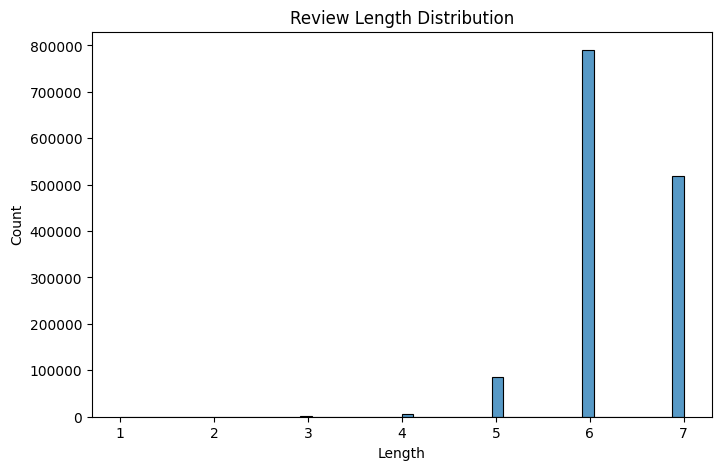

In [43]:
reviews['Review_Length'] = reviews['ReviewId'].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(reviews['Review_Length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

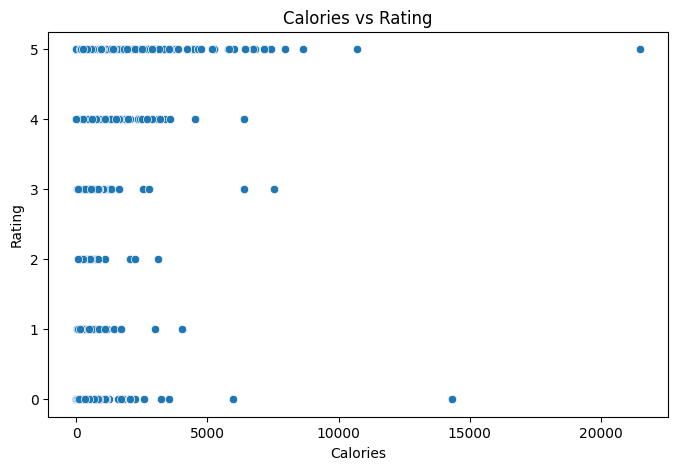

In [44]:
data_sample = data[['Rating', 'Calories']].dropna().sample(5000)

plt.figure(figsize=(8,5))
sns.scatterplot(x='Calories', y='Rating', data=data_sample)
plt.title("Calories vs Rating")
plt.show()

In [45]:
print("===== KEY INSIGHTS =====")

print("1. Dataset contains", recipes['RecipeId'].nunique(), "recipes")
print("2. Dataset contains", reviews['AuthorId'].nunique(), "users")
print("3. Ratings are skewed towards higher values (bias)")

print("4. Some recipes have significantly higher review counts")
print("5. Calories distribution is highly skewed")

print("6. Ingredients and categories can be used for content-based recommendation")
print("7. Reviews provide useful text for NLP/LLM applications")

===== KEY INSIGHTS =====
1. Dataset contains 522517 recipes
2. Dataset contains 271907 users
3. Ratings are skewed towards higher values (bias)
4. Some recipes have significantly higher review counts
5. Calories distribution is highly skewed
6. Ingredients and categories can be used for content-based recommendation
7. Reviews provide useful text for NLP/LLM applications
